<a href="https://colab.research.google.com/github/esprydi/sentimen-analisis-shopee-playstore/blob/master/Sentiment_Analisis_shopee_Playstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Scraping Dataset

In [2]:
#mengimpor pustaka google_play_scrapper

from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi
scrapreview = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=20000
)

In [3]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_shopee_app.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['review'])
    for review in scrapreview[0]: # Access the first element of the tuple which contains the list of reviews
        writer.writerow([review['content']])

# Loading Dataset

In [4]:
app_reviews_df = pd.DataFrame(scrapreview[0])
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('shopee_app_reviews.csv', index=None, header=True)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview[0])

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

# Menampilkan hasil
print(f"Jumlah ulasan: {jumlah_ulasan}")
print

Jumlah ulasan: 20000


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [5]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0f32ac46-b94e-42a5-83ad-e795d272665c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Bagus,Asli keamanannya bagus, aman juga lancar...",5,1,3.68.42,2026-03-10 06:30:09,"Hi kak Monika Irma, makasih bintang 5 nya, ak...",2026-03-10 08:45:50,3.68.42
1,675d7447-9df2-4eba-85b4-24660d842bb5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asli keamanannya bagus, aman juga lancar semua...",5,2,3.68.42,2026-03-03 12:39:10,"Hi kak misterius_, makasih ya buat review bint...",2026-03-03 14:25:07,3.68.42
2,faa9dab8-1efb-4209-80b8-2cbdbcd152e9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Banyak error, ya ampun lemot banget terutama b...",2,0,3.68.42,2026-03-09 11:56:59,"Hai kak Terrysha Cindy Auxilia, makasih ya bua...",2026-03-09 12:48:10,3.68.42
3,e5fa64c2-fcee-429e-8775-0644f584a59b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Top,Saya sangat suka belanja disini selain ban...",5,1,3.68.42,2026-03-10 07:31:47,"Hi kak Pipi Papi, maaf ya sudah buat kmu gak n...",2026-03-10 08:21:09,3.68.42
4,de9f9f78-fa9b-4521-b460-662470082749,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"shopee bagus ada fitur cod cek dulu ,minim pen...",4,0,3.69.32,2026-03-09 21:43:49,"Hai Kak Ika Pitriyani, maaf atas ketidaknyaman...",2026-03-10 02:39:56,3.69.32


In [6]:
# Menampilkan informasi
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20000 non-null  object        
 1   userName              20000 non-null  object        
 2   userImage             20000 non-null  object        
 3   content               20000 non-null  object        
 4   score                 20000 non-null  int64         
 5   thumbsUpCount         20000 non-null  int64         
 6   reviewCreatedVersion  19877 non-null  object        
 7   at                    20000 non-null  datetime64[ns]
 8   replyContent          18741 non-null  object        
 9   repliedAt             18741 non-null  datetime64[ns]
 10  appVersion            19877 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


In [7]:
# Membuat DataFrame baru dengan menghapus baris yang memiliki nilai yang hilang

clean_df = app_reviews_df.dropna()

In [8]:
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan,jumlah_kolom = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18624 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              18624 non-null  object        
 1   userName              18624 non-null  object        
 2   userImage             18624 non-null  object        
 3   content               18624 non-null  object        
 4   score                 18624 non-null  int64         
 5   thumbsUpCount         18624 non-null  int64         
 6   reviewCreatedVersion  18624 non-null  object        
 7   at                    18624 non-null  datetime64[ns]
 8   replyContent          18624 non-null  object        
 9   repliedAt             18624 non-null  datetime64[ns]
 10  appVersion            18624 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


# Preprocessing Text

In [12]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# --- 1. INISIALISASI ---
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text_tokens): # Menghapus stopwords dalam teks
    # Ambil stopwords dasar
    listStopwords = set(stopwords.words('indonesian'))
    # --- PENYELAMATAN NEGASI ---
    # Daftar kata yang TIDAK BOLEH dihapus karena penting untuk makna negatif
    negasi_penting = {"tidak", "bukan", "kurang", "jangan", "ga", "gak", "nggak"}
    for kata in negasi_penting:
        if kata in listStopwords:
            listStopwords.remove(kata)
    # Tambahkan kata-kata sampah spesifik Shopee/Playstore
    listStopwords.update(['dan', 'saya', 'dll', 'dkk', 'dsb', 'dst', 'yg', 'itu', 'ini',
        'adalah', 'ya', 'kak', 'shopee', 'aplikasi', 'nya', 'sih'])    # Filter: Simpan kata jika TIDAK ada di listStopwords ATAU mengandung "_"
    filtered = [w for w in text_tokens if (w not in listStopwords) or ("_" in w)]

    return filtered # Mengembalikan list, bukan string

# Buat kamus kosong untuk menyimpan kata yang sudah di-stem
stem_cache = {}

def stemmingText(text):
    words = text.split()
    stemmed_words = []

    for word in words:
        if word not in stem_cache:
            # Jika kata belum pernah di-stem, hitung dan simpan ke cache
            stem_cache[word] = stemmer.stem(word)
        stemmed_words.append(stem_cache[word])

    return ' '.join(stemmed_words)

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

def reduce_lengthening(text): # Normalisasi karakter berulang misal : bagusss jadi bagus
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def handle_negation(text):
    # Gunakan hanya kata baku karena slang sudah diperbaiki di step sebelumnya
    # "ga", "gak", "nggak" TIDAK perlu ada di sini jika sudah diubah jadi "tidak"
    negation_words = ["tidak", "bukan", "kurang", "jangan"]

    words = text.split()
    new_words = []
    i = 0
    while i < len(words):
        if words[i] in negation_words and i + 1 < len(words):
            combined_word = words[i] + "_" + words[i + 1]
            new_words.append(combined_word)
            i += 2
        else:
            new_words.append(words[i])
            i += 1
    return ' '.join(new_words)



In [13]:
slangwords = {"ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "bangettt": "banget", "skali": "sekali",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "kalo": "kalau", "kl": "kalau", "klo": "kalau",
    "jd": "jadi", "jdi": "jadi",
    "kmrn": "kemarin", "skrg": "sekarang", "skr": "sekarang",
    "lemot": "lambat", "lola": "lambat",
    "ongkir": "ongkos kirim", "cod": "bayar di tempat",
    "bales": "balas", "admin": "petugas",
    "pas": "ketika", "tp": "tapi", "tapi": "tetapi"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords[word] if word in slangwords else word for word in words]
    return ' '.join(fixed_words)


In [15]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Membersihkan teks (Hapus simbol, URL, Angka)
clean_df['step1_clean'] = clean_df['content'].apply(cleaningText)

# 2. Case Folding (Kecilkan huruf)
clean_df['step2_fold'] = clean_df['step1_clean'].apply(casefoldingText)

# 3. Reduce Lengthening (Bagusss -> Baguss)
clean_df['step3_reduce'] = clean_df['step2_fold'].apply(reduce_lengthening)

# 4. Fix Slangwords (ga -> tidak)
# Note: Fungsi ini masih pakai .split() internal untuk memproses kata
clean_df['step4_slang'] = clean_df['step3_reduce'].apply(fix_slangwords)

# 5. Handle Negation (tidak bagus -> tidak_bagus)
clean_df['step5_negation'] = clean_df['step4_slang'].apply(handle_negation)

# 6. TOKENIZING (DI SINI TEMPATNYA)
# Memecah kalimat menjadi list kata yang bersih dan sudah terikat negasi
clean_df['step6_token'] = clean_df['step5_negation'].apply(tokenizingText)

# 7. Filtering (Hapus Stopwords dari LIST token)

clean_df['step7_filter'] = clean_df['step6_token'].apply(filteringText)
# 8. To Sentence (Kembalikan ke kalimat untuk dihitung skor leksikonnya)
clean_df['text_akhir'] = clean_df['step7_filter'].apply(toSentence)

# # 9. Stemming (Opsional: Mengecilkan kata ke bentuk dasar)
# # Catatan: Jika data 18rb, proses ini mungkin butuh waktu 1-2 menit
# clean_df['text_akhir'] = clean_df['step8_sentence'].apply(stemmingText)

display(clean_df[['content', 'text_akhir']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,text_akhir
0,"Bagus,Asli keamanannya bagus, aman juga lancar...",bagusasli keamanannya bagus aman lancar terkom...
1,"Asli keamanannya bagus, aman juga lancar semua...",asli keamanannya bagus aman lancar terkombinas...
2,"Banyak error, ya ampun lemot banget terutama b...",error ampun lambat banget qris shopeepay jarin...
3,"Top,Saya sangat suka belanja disini selain ban...",topsaya suka belanja voucher belanja gratis on...
4,"shopee bagus ada fitur cod cek dulu ,minim pen...",bagus fitur bayar cek minim penipuan voucher d...


# Pelabelan

In [16]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. SETUP MODEL & TOKENIZER
pretrained = "mdhugol/indonesia-bert-sentiment-classification"
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

# Pastikan device=0 jika menggunakan GPU di Colab (Sangat disarankan untuk 10rb data)
device = 0 if torch.cuda.is_available() else -1
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# Index label sesuai dokumentasi
label_index = {'LABEL_0': 'Positive', 'LABEL_1': 'Neutral', 'LABEL_2': 'Negative'}

from torch.utils.data import DataLoader

# --- 2. FUNGSI PROSES BATCH (SENTIMEN + EMBEDDING) ---
def get_sentiment_and_embeddings(texts, batch_size=32):
    model.eval()
    model.to(device)

    all_labels = []
    all_scores = []
    all_embeddings = []

    # Memproses data dalam batch agar RAM tidak meledak
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]

        # Tokenisasi
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # Kita minta model mengeluarkan 'hidden_states' untuk embedding
            outputs = model(**inputs, output_hidden_states=True)

        # 1. Ekstrak Sentimen (Logits)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        scores, predictions = torch.max(probs, dim=-1)

        # 2. Ekstrak Embedding (Mengambil rata-rata hidden state terakhir / Mean Pooling)
        # last_hidden_state memiliki shape: [batch_size, sequence_length, 768]
        last_hidden = outputs.hidden_states[-1]
        mean_embedding = torch.mean(last_hidden, dim=1)

        all_labels.extend([label_index[f'LABEL_{p.item()}'] for p in predictions])
        all_scores.extend(scores.cpu().numpy())
        all_embeddings.extend(mean_embedding.cpu().numpy())

    return all_labels, all_scores, all_embeddings

# Jalankan Proses
list_texts = clean_df['content'].fillna("").astype(str).tolist()
labels, scores, embeddings = get_sentiment_and_embeddings(list_texts)

# --- 3. SIMPAN KE DATAFRAME ---
clean_df['sentiment'] = labels
clean_df['confidence_score'] = scores
clean_df['embedding'] = embeddings # Ini akan berisi list angka (vektor 768 dimensi)

print("\nSelesai! Sentimen dan Embedding berhasil diekstrak.")

# --- 4. CEK HASIL ---
print("\nDistribusi Sentimen (3 Kategori):")
print(clean_df['sentiment'].value_counts())
display(clean_df[['content', 'score', 'sentiment']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Selesai! Sentimen dan Embedding berhasil diekstrak.

Distribusi Sentimen (3 Kategori):
sentiment
Negative    10121
Positive     6476
Neutral      2027
Name: count, dtype: int64


,content,score,sentiment
0,"Bagus,Asli keamanannya bagus, aman juga lancar...",5,Positive
1,"Asli keamanannya bagus, aman juga lancar semua...",5,Positive
2,"Banyak error, ya ampun lemot banget terutama b...",2,Negative
3,"Top,Saya sangat suka belanja disini selain ban...",5,Negative
4,"shopee bagus ada fitur cod cek dulu ,minim pen...",4,Positive


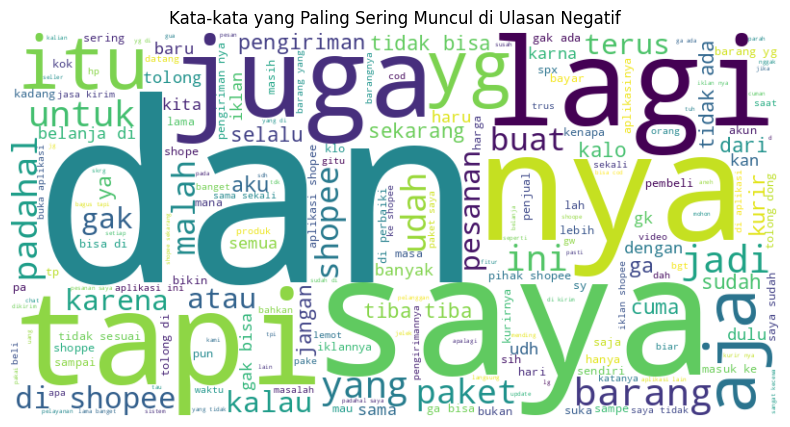

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil hanya ulasan yang negatif
negative_text = " ".join(clean_df[clean_df['sentiment'] == 'Negative']['content'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Kata-kata yang Paling Sering Muncul di Ulasan Negatif")
plt.show()

,count
sentiment,
Negative,10121
Positive,6476
Neutral,2027


/tmp/ipykernel_4221/1556481133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


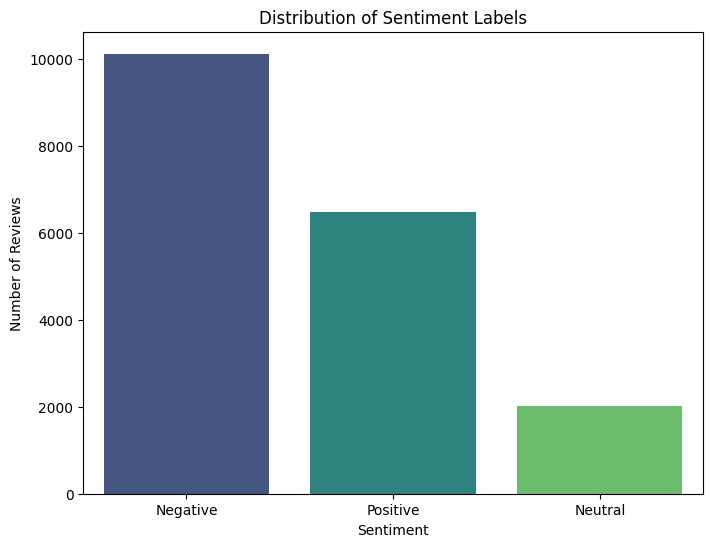

In [18]:
# Menghitung jumlah ulasan untuk setiap kategori sentimen
sentiment_counts = clean_df['sentiment'].value_counts()
display(sentiment_counts)

# Memvisualisasikan distribusi sentimen
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#Eksplorasi Label

# Data Splitting dan Ekstraksi Fitur dengN TF-IDF

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. PROSES TF-IDF (Ini yang tadi terlewat/belum terdefinisi)
# TF-IDF butuh teks dalam bentuk string
text_samples = clean_df['text_akhir'].astype(str)

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=2
)

# Membuat matriks X_tfidf
X_tfidf = tfidf_vectorizer.fit_transform(text_samples).toarray()

# 2. SIAPKAN KOMPONEN LAIN
y = clean_df['sentiment']
X_indobert = np.stack(clean_df['embedding'].values)
indobert_score = clean_df['confidence_score'].values.reshape(-1, 1)

# 3. GABUNGKAN (Sekarang X_tfidf sudah ada)
# Gabungkan TF-IDF (2000) + IndoBERT Embedding (768) + Score (1)
X_combined_tfidf = np.hstack((X_tfidf, X_indobert, indobert_score))

# 4. SPLIT DATA
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_combined_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# 5. SMOTE
smote_tfidf = SMOTE(random_state=42)
X_train_res_tfidf, y_train_res_tfidf = smote_tfidf.fit_resample(X_train_tfidf, y_train_tfidf)

print(f"Skenario TF-IDF + Embedding Siap!")
print(f"Jumlah Fitur Total: {X_train_res_tfidf.shape[1]}")
print(f"Distribusi setelah SMOTE: {Counter(y_train_res_tfidf)}")

Skenario TF-IDF + Embedding Siap!
Jumlah Fitur Total: 2769
Distribusi setelah SMOTE: Counter({'Negative': 8097, 'Positive': 8097, 'Neutral': 8097})


### Membuat Fitur Word2Vec

Langkah ini akan menghasilkan representasi vektor untuk setiap ulasan menggunakan model Word2Vec yang dilatih dari data teks yang sudah dibersihkan.

In [23]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Pastikan data adalah list of words (Tokenized)
# Kita pecah string 'text_akhir' menjadi list kata agar Word2Vec tidak belajar per huruf
word2vec_data = [text.split() for text in clean_df['text_akhir'].astype(str).tolist()]

# 2. Latih Ulang Model Word2Vec dengan benar
print("Melatih ulang model Word2Vec (Kata per Kata)...")
model_w2v = Word2Vec(sentences=word2vec_data, vector_size=300, window=5, min_count=5, workers=4, seed=42)

# 3. Fungsi Document Vector (Sama seperti sebelumnya)
def document_vector(word_list, model):
    vectors = [model.wv[word] for word in word_list if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# 4. Buat fitur X_w2v (300 fitur)
X_w2v = np.array([document_vector(words, model_w2v) for words in word2vec_data])

# 5. Siapkan Fitur Pendukung (IndoBERT)
X_indobert = np.stack(clean_df['embedding'].values) # 768 fitur
indobert_score = clean_df['confidence_score'].values.reshape(-1, 1) # 1 fitur

# 6. GABUNGKAN SEMUANYA (Total 1069 Fitur)
X_combined_w2v = np.hstack((X_w2v, X_indobert, indobert_score))

print(f"Hasil Akhir X_combined_w2v: {X_combined_w2v.shape}")

Melatih ulang model Word2Vec (Kata per Kata)...
Hasil Akhir X_combined_w2v: (18624, 1069)


In [24]:
# 1. Split Data
y = clean_df['sentiment']
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_combined_w2v, y, test_size=0.2, random_state=42, stratify=y
)

# 2. SMOTE
print("Menjalankan SMOTE untuk Skenario Word2Vec...")
smote_w2v = SMOTE(random_state=42)
X_train_res_w2v, y_train_res_w2v = smote_w2v.fit_resample(X_train_w2v, y_train_w2v)

print("\n--- STATUS FINAL SKENARIO WORD2VEC ---")
print(f"Jumlah Fitur: {X_train_res_w2v.shape[1]}")
print(f"Distribusi Kelas: {Counter(y_train_res_w2v)}")

Menjalankan SMOTE untuk Skenario Word2Vec...

--- STATUS FINAL SKENARIO WORD2VEC ---
Jumlah Fitur: 1069
Distribusi Kelas: Counter({'Negative': 8097, 'Positive': 8097, 'Neutral': 8097})


# Modeling Menggunakan TF IDF

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_tfidf = le.fit_transform(y_train_res_tfidf)
y_test_encoded_tfidf = le.transform(y_test_tfidf)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Neutral' 'Positive']


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Model dengan tambahan Tree Method (GPU) jika tersedia
xgb_model_tfidf = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=8,            # 12 mungkin terlalu dalam & lambat, 8 biasanya sweet spot
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.7,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',     # Ganti ke 'gpu_hist' jika pakai GPU Colab
    device='cuda'           # Tambahkan ini jika pakai GPU
)

# 2. Training
# Kita gunakan eval_set agar bisa melihat progress saat belajar
xgb_model_tfidf.fit(
    X_train_res_tfidf, y_train_encoded_tfidf,
    eval_set=[(X_test_tfidf, y_test_encoded_tfidf)],
    verbose=100             # Menampilkan hasil setiap 100 pohon
)

# 3. Prediksi
y_pred_xgb_tfidf = xgb_model_tfidf.predict(X_test_tfidf)

# 4. Evaluasi
print(f'\nXGBoost Accuracy (TF-IDF): {accuracy_score(y_test_encoded_tfidf, y_pred_xgb_tfidf):.4f}')
print(classification_report(y_test_encoded_tfidf, y_pred_xgb_tfidf, target_names=le.classes_))

[0]	validation_0-mlogloss:1.07445
[100]	validation_0-mlogloss:0.25991
[200]	validation_0-mlogloss:0.15568
[300]	validation_0-mlogloss:0.13498
[400]	validation_0-mlogloss:0.12946
[500]	validation_0-mlogloss:0.12683
[600]	validation_0-mlogloss:0.12566
[700]	validation_0-mlogloss:0.12493
[800]	validation_0-mlogloss:0.12446
[900]	validation_0-mlogloss:0.12411
[1000]	validation_0-mlogloss:0.12390
[1100]	validation_0-mlogloss:0.12386


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Model
lgbm_model_tfidf = LGBMClassifier(
    n_estimators=1200,       # Tambah pohon agar belajar lebih lama
    learning_rate=0.03,      # Belajar lebih teliti
    num_leaves=150,          # Leaf-wise growth yang lebih kompleks (khas LightGBM)
    max_depth=12,            # Batasi kedalaman agar tidak overfit
    min_data_in_leaf=20,     # Mencegah pohon terlalu spesifik pada satu data
    feature_fraction=0.8,    # Random sampling fitur (mirip colsample di XGBoost)
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    # class_weight='balanced' #DIHAPUS karena kita pakai data SMOTE
)

# 2. Training (WAJIB PAKAI HASIL SMOTE)
# Gunakan X_train_res dan y_train_encoded_res
lgbm_model_tfidf.fit(X_train_res_tfidf, y_train_encoded_tfidf)

# 3. Prediksi
y_pred_lgbm_tfidf = lgbm_model_tfidf.predict(X_test_tfidf)

# 4. Evaluasi
print('LightGBM Accuracy:', accuracy_score(y_test_encoded_tfidf, y_pred_lgbm_tfidf))
print("\nLaporan Klasifikasi LightGBM:")
print(classification_report(y_test_encoded_tfidf, y_pred_lgbm_tfidf, target_names=le.classes_))

# Modeling Menggunakan Word2Vec

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_word2vec = le.fit_transform(y_train_res_word2vec)
y_test_encoded_word2vec = le.transform(y_test_w2v)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score # Added accuracy_score

# 1. Inisialisasi Model
xgb_model_word2vec = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,     # Belajar sangat detail
    max_depth=12,           # Pohon lebih dalam untuk menangkap pola Neutral
    gamma=0.2,                # Menambah regularisasi agar tidak overfit
    subsample=0.8,          # Mengambil 80% data secara acak agar tidak overfit
    colsample_bytree=0.8,   # Mengambil 80% fitur secara acak
    objective='multi:softprob', # Changed to binary:logistic for 2 classes
    num_class=3,
    random_state=42,
    n_jobs=-1
)

# 2. Training (Pakai data SMOTE yang sudah di-encode)
xgb_model_word2vec.fit(X_train_res_word2vec, y_train_encoded_word2vec)

# 3. Prediksi
y_pred_xgb_word2vec = xgb_model_word2vec.predict(X_test_w2v) # Changed to X_test_w2v

# 4. Evaluasi (Ubah kembali angka ke teks label asli)
print('XGBoost Accuracy:', accuracy_score(y_test_encoded_word2vec, y_pred_xgb_word2vec))
print(classification_report(y_test_encoded_word2vec, y_pred_xgb_word2vec, target_names=le.classes_))

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Model
lgbm_model_word2vec = LGBMClassifier(
    n_estimators=1200,       # Tambah pohon agar belajar lebih lama
    learning_rate=0.03,      # Belajar lebih teliti
    num_leaves=150,          # Leaf-wise growth yang lebih kompleks (khas LightGBM)
    max_depth=12,            # Batasi kedalaman agar tidak overfit
    min_data_in_leaf=20,     # Mencegah pohon terlalu spesifik pada satu data
    feature_fraction=0.8,    # Random sampling fitur (mirip colsample di XGBoost)
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    # class_weight='balanced' #DIHAPUS karena kita pakai data SMOTE
)

# 2. Training (WAJIB PAKAI HASIL SMOTE)
# Gunakan X_train_res dan y_train_encoded_res
lgbm_model_word2vec.fit(X_train_res_word2vec, y_train_encoded_word2vec)

# 3. Prediksi
y_pred_lgbm_word2vec = lgbm_model_word2vec.predict(X_test_w2v) # Changed to X_test_w2v

# 4. Evaluasi
print('LightGBM Accuracy:', accuracy_score(y_test_encoded_word2vec, y_pred_lgbm_word2vec))
print("\nLaporan Klasifikasi LightGBM:")
print(classification_report(y_test_encoded_word2vec, y_pred_lgbm_word2vec, target_names=le.classes_))